In [ ]:
!pip -q install google-genai gradio xgboost shap reportlab joblib

In [ ]:
import pandas as pd

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib
import gradio as gr
from google import genai

In [ ]:
print(pd.__version__)

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
df = pd.read_csv("StudentPerformanceFactors.csv")

print("Dataset Loaded Successfully")

df.head()

In [ ]:
print("Shape:", df.shape)

print("\nColumn Names:\n")

print(df.columns.tolist())

print("\nMissing Values:\n")

print(df.isnull().sum())

In [ ]:
label_encoders = {}

for column in df.select_dtypes(include="object").columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

print("Categorical Encoding Completed")

In [ ]:
X = df.drop("Exam_Score", axis=1)

y = df["Exam_Score"]

print("Features:", X.shape)

print("Target:", y.shape)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

In [ ]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42
    )

}

In [ ]:
results = []

best_model = None
best_score = -100

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append([name, mae, rmse, r2])

    if r2 > best_score:

        best_score = r2

        best_model = model

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","R2 Score"]
)

results_df

In [ ]:
joblib.dump(best_model,"best_student_model.pkl")

print("Best Model Saved Successfully")

In [ ]:
print("="*50)
print("🏆 BEST MODEL")
print("="*50)

best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(),
    "Model"
]

print("Best Model :", best_model_name)
print("R² Score :", round(best_score,4))

In [ ]:
from google import genai
from google.colab import userdata

API_KEY = userdata.get("")
client = genai.Client(API_KEY)

print("Gemini Client Connected Successfully")

In [ ]:
response = client.models.generate_content(
    model="gemini-3.1-flash-lite",
    contents="Say hello in one sentence."
)

print(response.text)

In [ ]:
def generate_ai_report(score, attendance, study_hours):

    prompt = f"""
    You are an experienced academic mentor.

    Predicted Score: {score}
    Attendance: {attendance}%
    Study Hours: {study_hours}

    Generate a professional academic report in Markdown format.

    Use the following structure exactly:

    **Performance Summary**
    Write a brief summary.

    **Strengths**
    - Point 1
    - Point 2
    - Point 3

    **Weaknesses**
    - Point 1
    - Point 2
    - Point 3

    **Knowledge Application**
      Explain how the student can apply their learning in practical situations.

      **Personalized Study Plan**
      - Daily study plan
      - Weekly goals
      - Revision strategy

      **Motivation**
      Write a short motivational message.

      IMPORTANT:
      - Make all headings bold using Markdown (**Heading**).
      - Use bullet points.
      - Keep the report professional.
      """

    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite",
            contents=prompt
        )

        return response.text

    except Exception as e:
        return f"AI Report Generation Failed.\n\nError: {str(e)}"

In [ ]:
report = generate_ai_report(
    score=82,
    attendance=88,
    study_hours=5
)

print(report)

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(best_model.coef_)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

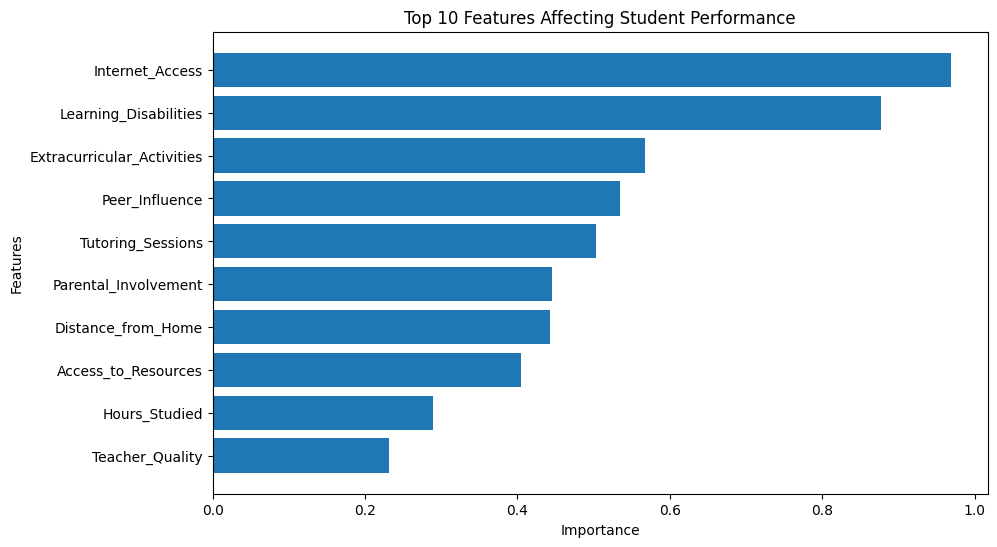

In [27]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Features Affecting Student Performance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

In [28]:
def risk_level(score):

    if score >= 80:
        return "🟢 Low Risk"

    elif score >= 60:
        return "🟡 Medium Risk"

    else:
        return "🔴 High Risk"

In [30]:
print("Score 92 :", risk_level(92))
print("Score 72 :", risk_level(72))
print("Score 45 :", risk_level(45))

Score 92 : 🟢 Low Risk
Score 72 : 🟡 Medium Risk
Score 45 : 🔴 High Risk


In [29]:
def predict_student(hours_studied, attendance, previous_score, sleep_hours,
                    tutoring_sessions, physical_activity):

    student = pd.DataFrame({
        "Hours_Studied": [hours_studied],
        "Attendance": [attendance],
        "Previous_Scores": [previous_score],
        "Sleep_Hours": [sleep_hours],
        "Tutoring_Sessions": [tutoring_sessions],
        "Physical_Activity": [physical_activity]
    })

    # Fill remaining columns with 0
    for col in X.columns:
        if col not in student.columns:
            student[col] = 0

    # Match training column order
    student = student[X.columns]

    # Predict score
    score = float(best_model.predict(student)[0])

    # Risk Level
    if score >= 80:
        risk = "🟢 Low Risk"
    elif score >= 60:
        risk = "🟡 Medium Risk"
    else:
        risk = "🔴 High Risk"

    # AI Report
    report = generate_ai_report(
        round(score, 2),
        attendance,
        hours_studied
    )

    return round(score, 2), risk, report

In [31]:
print(type(df))
print(type(X))
print(type(y))
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [32]:
print("best_model:", type(best_model))
print("X:", type(X))
print("client:", type(client))

best_model: <class 'sklearn.linear_model._base.LinearRegression'>
X: <class 'pandas.core.frame.DataFrame'>
client: <class 'google.genai.client.Client'>


In [33]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("# 🎓 MentorMind AI")
    gr.Markdown("### Intelligent Student Performance Prediction & AI Learning Assistant")

    with gr.Row():

        with gr.Column():

            hours = gr.Slider(0, 12, value=5, label="Hours Studied")

            attendance = gr.Slider(0, 100, value=80, label="Attendance (%)")

            previous = gr.Slider(0, 100, value=75, label="Previous Score")

            sleep = gr.Slider(0, 12, value=7, label="Sleep Hours")

            tutoring = gr.Slider(0, 10, value=2, label="Tutoring Sessions")

            physical = gr.Slider(0, 5, value=2, label="Physical Activity")

            predict_btn = gr.Button("🚀 Predict")

        with gr.Column():
            gr.Markdown("### 📘 AI Academic Report")

            score = gr.Number(label="Predicted Score")

            risk = gr.Textbox(label="Risk Level")

            report = gr.Markdown(

            )

    predict_btn.click(
        fn=predict_student,
        inputs=[
            hours,
            attendance,
            previous,
            sleep,
            tutoring,
            physical
        ],
        outputs=[
            score,
            risk,
            report
        ]
    )

In [34]:
for model in [
    "gemini-3.5-flash",
    "gemini-flash-latest",
    "gemini-3.1-flash-lite",
    "gemini-3-flash-preview"
]:
    try:
        response = client.models.generate_content(
            model=model,
            contents="Say hello"
        )
        print(f"✅ {model} works")
        print(response.text)
        break
    except Exception as e:
        print(f"❌ {model} -> {e}")

✅ gemini-3.5-flash works
Hello! How can I help you today?


In [35]:
import joblib

joblib.dump(best_model, "mentormind_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b6ae4ad5576f26482a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
